In [1]:
%matplotlib inline

import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from multiprocessing import Pool
from tqdm import tqdm
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

import k3d

In [2]:
def euclidean_distance(node1, node2):
    """
    Calculate the Euclidean distance between two nodes.

    Parameters:
    node1, node2 (dict): Nodes with 'pos' key containing x, y, z coordinates.

    Returns:
    float: Euclidean distance between node1 and node2.
    """
    pos1 = np.array(node1['pos'])
    pos2 = np.array(node2['pos'])
    return np.linalg.norm(pos1 - pos2)

def add_node_to_graph(graph, node):
    """
    Add a node with attributes to the graph.

    Parameters:
    graph (nx.DiGraph): The graph to which the node will be added.
    node (dict): Node data.
    """
    graph.add_node(
        node['sampleNumber'], 
        pos=(node['x'], node['y'], node['z']), 
        radius=node['radius'], 
        structure_id=node['structureIdentifier'],
        allen_id=node['allenId']
    )

def add_edge_to_graph(graph, parent, child):
    """
    Add an edge between parent and child nodes in the graph, with weight as Euclidean distance.

    Parameters:
    graph (nx.DiGraph): The graph to which the edge will be added.
    parent, child (int): The sampleNumbers of the parent and child nodes.
    """
    graph.add_edge(
        parent, 
        child, 
        weight=euclidean_distance(
            graph.nodes()[parent],
            graph.nodes()[child]
        )
    )


def json_to_digraph(file_path):
    """
    Load a neuronal reconstruction from a JSON file into a NetworkX graph.

    The JSON file contains SWC data with additional brain region information for each node.
    The graph will be a directed tree.

    Parameters:
    file_path (str): Path to the JSON file containing reconstruction data.

    Returns:
    nx.DiGraph: A directed graph representing the neuronal tree.
    """
    try:
        with open(file_path, 'r') as file:
            data = json.load(file)
    except IOError as e:
        print(f"Error opening file: {e}")
        return None

    # Certain JSON files may have a single 'neuron' object instead of a 'neurons' array
    neuron_data = data['neuron'] if 'neuron' in data else data['neurons'][0]

    axon_graph, dendrite_graph = nx.DiGraph(), nx.DiGraph()

    for structure, graph in [('dendrite', dendrite_graph), ('axon', axon_graph)]:
        if structure not in neuron_data:
            # Some reconstructions may be missing an axon or dendrite tracing
            print(f"Missing structure {structure} for {file_path}")
            continue
        for node in sorted(neuron_data[structure], key=lambda x: x['sampleNumber']):
            add_node_to_graph(graph, node)
            if node['parentNumber'] != -1:
                add_edge_to_graph(graph, node['parentNumber'], node['sampleNumber'])
                
    if dendrite_graph.nodes() and axon_graph.nodes():
        # Remove duplicate soma node from axon graph
        axon_graph.remove_node(1)  

    # The sampleNumber starts at 1 for both axon and dendrite, so 
    # relabel axon nodes to avoid key collisions when merging the graphs,.
    first_axon_label = max(dendrite_graph.nodes()) + 1 if dendrite_graph.nodes() else 1
    joined_graph = nx.union(
        dendrite_graph, 
        nx.convert_node_labels_to_integers(
            axon_graph, 
            first_label=first_axon_label
        )
    )
    roots = [n for n in joined_graph if joined_graph.in_degree(n) == 0]
    # Link the dendrite to the axon
    if len(roots) == 2:
        add_edge_to_graph(joined_graph, roots[0], roots[1])

    return file_path, joined_graph

# Define a function for filtering the graph based on attribute values
def get_subgraph(G, attribute, values):
    """
    Extract a subgraph from the given graph based on specified attribute values.

    Parameters:
    G (nx.Graph): The original graph from which to extract the subgraph.
    attribute (str): The node attribute used for filtering.
    values (tuple): A tuple of attribute values to include in the subgraph.

    Returns:
    nx.Graph: A subgraph of G containing only nodes with the specified attribute values.
    """
    filtered_nodes = [node for node, attr in G.nodes(data=True) if attr.get(attribute) in values]
    return G.subgraph(filtered_nodes)

def load_graphs(filepaths):
    """
    Load all JSON files in the given directory as graphs using multiprocessing.

    Parameters:
    directory_path (str): Path to the directory containing JSON files.

    Returns:
    list of nx.Graph: A list of graphs loaded from the JSON files.
    """
    # Use multiprocessing pool to load graphs in parallel
    with Pool() as pool:
        # graphs = tqdm(pool.imap(json_to_digraph, filepaths), total=len(filepaths))
        graphs = pool.map(json_to_digraph, filepaths)

    # Organize into dictionary
    return {os.path.splitext(os.path.split(fn)[1])[0] : graph for fn, graph in graphs}


def get_cells_in_regions(manifest_path, acronyms):
    # Load the CSV file
    df = pd.read_csv(manifest_path)

    # If a single acronym is provided, convert it to a list
    if isinstance(acronyms, str):
        acronyms = [acronyms]

    # Filter the dataframe for the specified acronyms and get the filenames
    filtered_df = df[df['soma_acronym'].isin(acronyms)]
    filenames = filtered_df['filename'].tolist()
    filtered_acronyms = filtered_df['soma_acronym'].tolist()

    return filenames, filtered_acronyms

In [3]:
# Get CCF lookups
from collections import defaultdict
ccf_structures = pd.read_csv('/data/allen_mouse_ccf/annotation/adult_mouse_ccf_structures.csv')
id_to_acronym = defaultdict(lambda: "NaN")
id_to_acronym = id_to_acronym | ccf_structures.set_index('id')['acronym'].to_dict()
acronym_to_id = {acronym: ccf_id for ccf_id, acronym in id_to_acronym.items()}
id_to_parent = ccf_structures.set_index('id')['parent_structure_id'].to_dict()
id_to_parent[None] = None # to account for out of bands points

In [4]:
# Create pathing dictionaries to group children CCF levels
rois = ["CB","MY","P","MB","TH","HY","CNU","CTXsp","HPF","OLF","Isocortex","fiber tracts","VS","grv","retina"] # remove "fiber tracts","VS","grv","retina" later
roiIDs = [acronym_to_id[roi] for roi in rois]
# Get the pathing for each leaf node, find which roi each belongs to
id_to_path = ccf_structures.set_index("id")["structure_id_path"].to_dict()
# Create a new dictionary corresponding each CCF copartment to matching ROI
# id_to_roi = {}
id_to_roi = defaultdict(lambda: np.nan)
# For each CCF compartment, break down path and find matching ROI
for key, val in id_to_path.items():
    # Break down path 
    pathList = [int(struct) for struct in val.split("/") if struct]
    # Find matching ROI (should be empty, or a single element)
    roiList = [id for id in roiIDs if id in pathList]
    if not roiList:
        id_to_roi[key] = np.nan
    else:
        id_to_roi[key] = roiList[0]

# To check which values are uanccounted for
# [id_to_acronym[struct] for struct in [key for key, val in id_to_roi.items() if np.isnan(val)]]

In [5]:
# Assemble list of LC neurons and their genotypes
genotypeDict = {}
folderPath = Path("../data/")
filePaths = []
for folder in os.listdir(folderPath):
    dataPath = folderPath / folder / "Complete_annotated"
    if "685222_12_5_24" in str(dataPath):
        print("Skipping " + str(dataPath) + " due to duplicates.")
        continue
    if os.path.exists(dataPath):
        filePaths.append([os.path.join(dataPath,fn) for fn in os.listdir(dataPath) if fn.endswith(".json")])
        subjectPath = dataPath.parent / "subject.json"
        with open(subjectPath) as f:
            subjectJSON = json.load(f)
        genotypeDict[subjectJSON["subject_id"]] = subjectJSON["genotype"]
# filePaths = [os.path.join(folderPath,fn) for fn in os.listdir(folderPath) if fn.endswith(".json")]

filePaths = [file for files in filePaths for file in files]

In [6]:
# Load neurons
graphs = load_graphs(filePaths)

Missing structure dendrite for ../data/685221_12_5_24/Complete_annotated/N064-68221-JN.json
Missing structure dendrite for ../data/685221_12_5_24/Complete_annotated/N025-685221-PG.json
Missing structure axon for ../data/685221_12_5_24/Complete_annotated/N064-685221-JN.json
Missing structure dendrite for ../data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json
Missing structure dendrite for ../data/648434_12_5_24/Complete_annotated/N024-648434-SS.json


In [7]:
# Assemble neuron information into dicts, and then dataframe
i = 0
datasetDicts = {}
for key, val in graphs.items():
    neuronID, sample, annotator = key.split("-")
    try:
        soma = [node for node in val.nodes() if val.nodes[node]["structure_id"] == 1] # Get soma nodes
        assert len(soma) == 1
        genotype = genotypeDict[sample]
        x, y, z = val.nodes[soma[0]]["pos"]
    except Exception as e:
        print(f"Error finding structures for: {key}, dropping from dataframe")
        continue
    neuronDict = {"Graph":key, "ID":neuronID, "Sample":sample, "Annotator":annotator, "Genotype":genotype, "somaAP":x, "somaDV":y, "somaML":z}
    datasetDicts[i] = neuronDict
    i = i + 1

dataDF = pd.DataFrame.from_dict(datasetDicts, orient="index")

Error finding structures for: N025-685221-PG, dropping from dataframe
Error finding structures for: N064-68221-JN, dropping from dataframe
Error finding structures for: N064-685221-JN, dropping from dataframe
Error finding structures for: N051-685221 -YP, dropping from dataframe
Error finding structures for: N024-648434-SS, dropping from dataframe


In [8]:
# Reflect graphs so all neuron somas are on the left hemisphere
mlMidline = 5700
mlReflection = mlMidline*2

# Add column for original soma side
dataDF["somaOnRight"] = dataDF["somaML"] > mlMidline

# Reflect rightside graphs across midline
for index, row in dataDF.iterrows():
    # Grab neurons with somas on right
    if row["somaOnRight"]:
        graph = graphs[row["Graph"]]
        # Update soma position in dataframe
        dataDF.loc[index,"somaML"] = mlReflection - dataDF.loc[index,"somaML"]
        # Reflect every node's position along ML axis
        for node in graph.nodes:
            graph.nodes[node]["pos"] = (graph.nodes[node]["pos"][0], graph.nodes[node]["pos"][1], mlReflection - graph.nodes[node]["pos"][2])

In [9]:
# Exclude any neurons that need to be excluded
excludeList = [ # Look like MY cells mistakenly included in LC batch
    "N039-685222-AK",
    "N040-685222-VM",
    "N066-685221-JN",
    "N068-685221-HD",
    "N067-685221-HS"
]

dataDF = dataDF.drop(dataDF[dataDF["Graph"].isin(excludeList)].index).reset_index()

In [10]:
dataDF

,index,Graph,ID,Sample,Annotator,Genotype,somaAP,somaDV,somaML,somaOnRight
0,0,N001-685221-PG,N001,685221,PG,Dbh-Cre-KI/wt,10201.6760,4571.1625,4612.8491,False
1,1,N003-685221-HS,N003,685221,HS,Dbh-Cre-KI/wt,10481.6138,4402.5699,4750.0097,True
2,2,N009-685221-VM,N009,685221,VM,Dbh-Cre-KI/wt,10130.3109,4011.5415,4777.1360,True
3,3,N005-685221-JN,N005,685221,JN,Dbh-Cre-KI/wt,10327.1596,4178.1452,4807.0124,True
4,4,N011-685221-SP,N011,685221,SP,Dbh-Cre-KI/wt,10307.7860,4087.2135,4826.8439,True
...,...,...,...,...,...,...,...,...,...,...
103,108,N006-648434-JN,N006,648434,JN,Dbh-Cre-KI/wt,9709.7926,5022.2970,3873.3075,True
104,109,N026-648434-PG,N026,648434,PG,Dbh-Cre-KI/wt,9805.1909,5907.0996,4330.8163,False
105,110,N012-648434-JN,N012,648434,JN,Dbh-Cre-KI/wt,9697.7129,4986.8796,4210.2224,True
106,111,N025-648434-PG,N025,648434,PG,Dbh-Cre-KI/wt,10345.3048,4778.6333,4901.0922,False


#### Get non-LC neurons

In [9]:
# Assemble list of LC neurons and their genotypes
genotypeDict = {}
folderPathNonLC = Path("../data/non-LC+neurons")
filePathsNonLC = []
for fn in os.listdir(folderPathNonLC):
    # dataPath = folderPathNonLC / folder / "Complete_annotated"
    # filePathsNonLC.append([os.path.join(folderPathNonLC,fn) for fn in os.listdir(folderPathNonLC) if fn.endswith(".json")])
    if fn.endswith(".json"):
        filePathsNonLC.append(os.path.join(folderPathNonLC,fn))

# filePathsNonLC = [file for files in filePaths for file in files]
# filePathsNonLC = [file for files in filePathsNonLC for file in files] # unpack list of lists

In [10]:
# Load neurons
graphsNonLC = load_graphs(filePathsNonLC)

Missing structure dendrite for ../data/non-LC+neurons/N039-715345-DS .json
Missing structure dendrite for ../data/non-LC+neurons/N015-7154345-DS.json
Missing structure axon for ../data/non-LC+neurons/N015-715345-DS.json
Missing structure axon for ../data/non-LC+neurons/N039-715345-DS.json
Missing structure axon for ../data/non-LC+neurons/N096-708369-YP.json


In [11]:
# Assemble neuron information into dicts, and then dataframe
i = 0
datasetDicts = {}
for key, val in graphsNonLC.items():
    neuronID, sample, annotator = key.split("-")
    try:
        soma = [node for node in val.nodes() if val.nodes[node]["structure_id"] == 1] # Get soma nodes
        assert len(soma) == 1
        x, y, z = val.nodes[soma[0]]["pos"]
    except Exception as e:
        print(f"Error finding structures for: {key}, dropping from dataframe")
        continue
    neuronDict = {"Graph":key, "ID":neuronID, "Sample":sample, "Annotator":annotator, "somaAP":x, "somaDV":y, "somaML":z}
    datasetDicts[i] = neuronDict
    i = i + 1

dataDFNonLC = pd.DataFrame.from_dict(datasetDicts, orient="index")

Error finding structures for: N039-715345-DS , dropping from dataframe
Error finding structures for: N015-7154345-DS, dropping from dataframe
Error finding structures for: N015-715345-DS, dropping from dataframe
Error finding structures for: N039-715345-DS, dropping from dataframe
Error finding structures for: N096-708369-YP, dropping from dataframe


In [43]:
dataDF["isLC"] = True
dataDFNonLC["isLC"] = False
dataDF = pd.concat([dataDF,dataDFNonLC])

In [73]:
graphs.update(graphsNonLC)

## Measure

In [48]:
def get_ipsi_nodes(graph, nodes, region):
    return {i for i, node in nodes if node['allen_id'] == region and node["structure_id"] == 2 and node["pos"][2] <= mlMidline}

def get_contra_nodes(graph, nodes, region):
    return {i for i, node in nodes if node['allen_id'] == region and node["structure_id"] == 2 and node["pos"][2] > mlMidline}

funcDict = {"ipsi":get_ipsi_nodes, "contra":get_contra_nodes}

In [75]:
# Get list of unique regions
region_lengths = {}
lengthDict = {}

normalize_df = True
sides = ["ipsi","contra"]
for i, graph in graphs.items():
    # Assemble all nodes and edges
    nodes = graph.nodes(data=True)
    edges = graph.edges()
        
    regions = {node['allen_id'] for _, node in nodes}
    sideDict = {side : {} for side in sides}
    # For each region, sum edge weights
    for region in regions:
        for side in sides:
            # Filter nodes in the given region
            # nodes_in_region = {i for i, node in nodes if node['allen_id'] == region and node["structure_id"] == 2}

            # Filter nodes in the given region on the given side
            nodes_in_region = funcDict[side](graph, nodes,region)
        
            # Include edges where at least one node is in the region
            edges_in_region = [(u, v) for u, v in edges if u in nodes_in_region or v in nodes_in_region]
        
            # Calculate the total length of edges within the region
            total_length = sum(graph[u][v]['weight'] for u, v in edges_in_region)

            # Store the result in the dictionary
            sideDict[side][region] = total_length

    # Sum length within regions of interest
    roi_lengths = defaultdict(np.float64)
    for side, region_lengths in sideDict.items():
        for key, val in region_lengths.items():
            roi_lengths[id_to_acronym[id_to_roi[key]]+side] += val

    lengthDict[i] = roi_lengths
    # lengthDict[i] = {id_to_acronym[key]: val for key, val in roi_lengths.items()}

# Convert to dataframe
dfLengths = pd.DataFrame.from_dict(lengthDict, orient='index').fillna(0)
dfLengths.rename(columns={'NaNipsi': 'Otheripsi','NaNcontra': 'Othercontra'}, inplace=True) # Rename "NaN" to "Other"

if normalize_df:
    # Try convert to z-scores
    # dfLengths = (dfLengths - dfLengths.mean()) / dfLengths.std()

    # Try normalizing to maximum in each column
    # dfLengths = dfLengths / dfLengths.max()

    # Try normalizing to axonal length within a cell
    dfLengths = dfLengths.divide(dfLengths.sum(axis=1),axis=0)


In [76]:
# sorted_columns = sorted(dfLengths.columns)
sorted_columns = ["OLF","Isocortex","HPF","CTXsp","CNU","TH","HY","MB","P","MY","CB","Other"] # manually sort loosely anterior to posterior
sorted_side_columns = [col + side for col in sorted_columns[:-1] for side in sides] ##### REMOVING OTHER
sides = ["contra","ipsi"]
sorted_side_columns = [col + side for side in sides for col in sorted_columns[:-1]] ##### REMOVING OTHER
dfLengths = dfLengths[sorted_side_columns] # Reorder the DataFrame based on sorted column names
dfLengths.head(5)

,OLFcontra,Isocortexcontra,HPFcontra,CTXspcontra,CNUcontra,THcontra,HYcontra,MBcontra,Pcontra,MYcontra,...,Isocortexipsi,HPFipsi,CTXspipsi,CNUipsi,THipsi,HYipsi,MBipsi,Pipsi,MYipsi,CBipsi
N001-685221-PG,0.000000,0.00000,0.0,0.0,0.000000,0.006124,0.018036,0.021193,0.000000,0.086975,...,0.002677,0.000000,0.000000,0.016186,0.102473,0.003457,0.239843,0.045013,0.262123,0.000000
N003-685221-HS,0.000000,0.00000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.090425,...,0.722092,0.020879,0.000470,0.026368,0.008442,0.021340,0.009750,0.016468,0.017893,0.000000
N009-685221-VM,0.000000,0.00000,0.0,0.0,0.002547,0.032136,0.013761,0.028916,0.012718,0.025518,...,0.619902,0.014554,0.014866,0.026692,0.005952,0.016277,0.028926,0.007451,0.014124,0.000000
N005-685221-JN,0.021475,0.06589,0.0,0.0,0.001178,0.000000,0.000917,0.006074,0.000000,0.000000,...,0.657326,0.002030,0.002092,0.016672,0.015244,0.023151,0.070653,0.009941,0.000000,0.002435
N011-685221-SP,0.000000,0.00000,0.0,0.0,0.003447,0.029757,0.000669,0.001412,0.000000,0.000000,...,0.453770,0.207486,0.029324,0.013168,0.022625,0.007044,0.020651,0.004146,0.000000,0.002633


In [77]:
a = dataDF.copy()
b = dfLengths.copy()
plotDF = a.merge(b, left_on="Graph", right_index=True)
plotDF = plotDF.sort_values("somaDV",ascending=False)

In [78]:
dfRois = ['Isocortexipsi', 'fiber tractsipsi', 'CNUipsi', 'HPFipsi', 'MYipsi',
       'Pipsi', 'MBipsi', 'THipsi', 'CTXspipsi', 'HYipsi', 'OLFipsi', 'VSipsi',
       'CBipsi', 'Isocortexcontra', 'fiber tractscontra',
       'CNUcontra', 'HPFcontra', 'MYcontra', 'Pcontra', 'MBcontra', 'THcontra',
       'CTXspcontra', 'HYcontra', 'OLFcontra', 'VScontra',
       'CBcontra']

In [79]:
dfLengths = pd.DataFrame.from_dict(lengthDict, orient='index').fillna(0)
dfLengths.rename(columns={'NaNipsi': 'Otheripsi','NaNcontra': 'Othercontra'}, inplace=True) # Rename "NaN" to "Other"
dfLengths["Total"] = dfLengths[dfRois].sum(axis=1)
dfLengths[dfRois] = dfLengths[dfRois].divide(dfLengths["Total"],axis=0)
dfLengths["Total"] = dfLengths["Total"] / dfLengths["Total"].max()
# dfLengths = dfLengths.divide(dfLengths.sum(axis=1),axis=0)


a = dataDF.copy()
b = dfLengths.copy()
plotDF = a.merge(b, left_on="Graph", right_index=True)
plotDF = plotDF.sort_values("somaDV",ascending=False)

In [80]:
plotManualDF = plotDF.copy()

ctxAndSc = ['N030-685222-NM',
 'N048-685221-VM',
 'N044-685221-DS',
 'N014-685221-YV',
 'N022-685221-YP',
 'N054-685221-HS',
 'N052-685221-BP',
 'N041-685221-JN',
 'N038-685221-HS',
 'N005-685222-YP',
 'N021-685222-NM',
 'N016-685221-PG',
 'N035-685221-DS',
 'N016-685222-YP',
 'N004-685222-BP',
 'N010-685222-VM']

ibAndSc = ['N001-685221-PG',
 'N043-685221-HD',
 'N006-685222-DS',
 'N007-685222-BP',
 'N026-685222-SA',
 'N051-685221-YP',
 'N066-685221-JN',
 'N039-685222-AK',
 'N056-685221-AK',
 'N042-685221-HD']

noCtxAndSc = ["N009-648434-KV", "N045-685221-VM","N034-685222-HD","N034-685221-VM","N057-685221-AP","N036-685221-YP",
                   "N020-685221-BP", "N015-685222-VM", "N055-685221-JN", "N058-685221-JN", "N046-685221-SA", "N060-685221-YV",
                   "N025-648434-PG", "N013-685221-DS", "N012-685222-BP", "N013-685222-DS", "N050-685221-HD", "N024-685221-VM", 
                   "N008-685222-HD", "N009-685222-SP", "N024-685222-AP", "N059-685221-SA", "N012-648434-JN", "N006-648434-JN",
                   "N025-685222-SA", "N061-685221-YP", "N030-685221-VM", "N026-648434-PG"]

# dataDF[dataDF["Graph"].isin(ctxAndSc)]
plotManualDF["Proj"] = "No Ctx"
plotManualDF.loc[plotManualDF["Isocortexipsi"] > 0,"Proj"] = "Some Ctx"
plotManualDF.loc[plotManualDF["Isocortexcontra"] > 0,"Proj"] = "Some Ctx"
plotManualDF.loc[plotManualDF["Graph"].isin(ctxAndSc),"Proj"] = "Ctx and Sp. C."
plotManualDF.loc[plotManualDF["Graph"].isin(ibAndSc),"Proj"] = "IB and Sp. C."
plotManualDF["isSpinalProjecting"] = False
plotManualDF.loc[plotManualDF["Proj"].isin(["Ctx and Sp. C.","IB and Sp. C."]),"isSpinalProjecting"] = True
plotManualDF.loc[plotManualDF["Graph"].isin(noCtxAndSc),"isSpinalProjecting"] = True

In [81]:
# lengthDict = lateralLengthDict
dfLengths = pd.DataFrame.from_dict(lengthDict, orient='index').fillna(0)
dfLengths.rename(columns={'NaNipsi': 'Otheripsi','NaNcontra': 'Othercontra'}, inplace=True) # Rename "NaN" to "Other"
dfLengths["Total Length(cm)"] = dfLengths[dfRois].sum(axis=1) / 10000
plotManualDF.merge(dfLengths,left_on="Graph",right_index=True)

,index,Graph,ID,Sample,Annotator,Genotype,somaAP,somaDV,somaML,somaOnRight,...,CNUcontra_y,HPFipsi_y,CTXspipsi_y,OLFipsi_y,CBipsi_y,HPFcontra_y,CTXspcontra_y,OLFcontra_y,CBcontra_y,Total Length(cm)
17,NaN,N039-674185-SK,N039,674185,SK,NaN,11438.5901,7214.4111,6357.4032,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.861967
27,NaN,N022-674191-VM,N022,674191,VM,NaN,12523.2950,7092.5792,4748.9868,NaN,...,0.000000,0.000000,0.000000,0.000000,49760.673075,0.000000,0.000000,0.000000,11156.260844,9.681644
40,NaN,N021-674191-AS,N021,674191,AS,NaN,12422.6660,6968.4411,6624.0863,NaN,...,0.000000,0.000000,0.000000,0.000000,14143.597342,0.000000,0.000000,0.000000,13503.955745,5.451303
29,NaN,N020-674191-HP,N020,674191,HP,NaN,12404.9312,6957.5918,4761.1344,NaN,...,0.000000,0.000000,0.000000,0.000000,60934.122074,0.000000,0.000000,0.000000,15614.285057,12.446146
33,NaN,N019-674191-JN,N019,674191,JN,NaN,12316.1806,6953.9072,6771.9923,NaN,...,0.000000,0.000000,0.000000,0.000000,26427.302556,0.000000,0.000000,0.000000,39448.242473,10.488561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,107.0,N009-648434-KV,N009,648434,KV,Dbh-Cre-KI/wt,9963.9391,4052.6924,4917.9727,False,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.062352
2,2.0,N009-685221-VM,N009,685221,VM,Dbh-Cre-KI/wt,10130.3109,4011.5415,4777.1360,True,...,1284.145317,7338.863871,7495.971286,27110.553641,0.000000,0.000000,0.000000,0.000000,0.000000,50.088967
16,NaN,N014-715345-SP,N014,715345,SP,NaN,6711.2357,3860.5288,5043.4168,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.862456
107,112.0,N021-648434-PG,N021,648434,PG,Dbh-Cre-KI/wt,9981.7118,3798.5471,4966.5825,False,...,0.000000,0.000000,0.000000,0.000000,611.699008,0.000000,0.000000,0.000000,14346.202139,2.424835


In [82]:
axon_branch_dict = {}
for name in dataDF["Graph"]:
    graph = graphs[name]
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    axon_branch_dict[name] = len(axon_branch_nodes)

In [83]:
dfLengths = dfLengths.merge(pd.DataFrame.from_dict(axon_branch_dict, orient='index', columns = ["Axon Branches"]),
            left_index=True, right_index=True)

In [84]:
plotManualDF.merge(dfLengths,left_on="Graph",right_index=True)

,index,Graph,ID,Sample,Annotator,Genotype,somaAP,somaDV,somaML,somaOnRight,...,HPFipsi_y,CTXspipsi_y,OLFipsi_y,CBipsi_y,HPFcontra_y,CTXspcontra_y,OLFcontra_y,CBcontra_y,Total Length(cm),Axon Branches
17,NaN,N039-674185-SK,N039,674185,SK,NaN,11438.5901,7214.4111,6357.4032,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.861967,4255
27,NaN,N022-674191-VM,N022,674191,VM,NaN,12523.2950,7092.5792,4748.9868,NaN,...,0.000000,0.000000,0.000000,49760.673075,0.000000,0.000000,0.000000,11156.260844,9.681644,418
40,NaN,N021-674191-AS,N021,674191,AS,NaN,12422.6660,6968.4411,6624.0863,NaN,...,0.000000,0.000000,0.000000,14143.597342,0.000000,0.000000,0.000000,13503.955745,5.451303,172
29,NaN,N020-674191-HP,N020,674191,HP,NaN,12404.9312,6957.5918,4761.1344,NaN,...,0.000000,0.000000,0.000000,60934.122074,0.000000,0.000000,0.000000,15614.285057,12.446146,668
33,NaN,N019-674191-JN,N019,674191,JN,NaN,12316.1806,6953.9072,6771.9923,NaN,...,0.000000,0.000000,0.000000,26427.302556,0.000000,0.000000,0.000000,39448.242473,10.488561,265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,107.0,N009-648434-KV,N009,648434,KV,Dbh-Cre-KI/wt,9963.9391,4052.6924,4917.9727,False,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.062352,105
2,2.0,N009-685221-VM,N009,685221,VM,Dbh-Cre-KI/wt,10130.3109,4011.5415,4777.1360,True,...,7338.863871,7495.971286,27110.553641,0.000000,0.000000,0.000000,0.000000,0.000000,50.088967,571
16,NaN,N014-715345-SP,N014,715345,SP,NaN,6711.2357,3860.5288,5043.4168,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.862456,785
107,112.0,N021-648434-PG,N021,648434,PG,Dbh-Cre-KI/wt,9981.7118,3798.5471,4966.5825,False,...,0.000000,0.000000,0.000000,611.699008,0.000000,0.000000,0.000000,14346.202139,2.424835,20


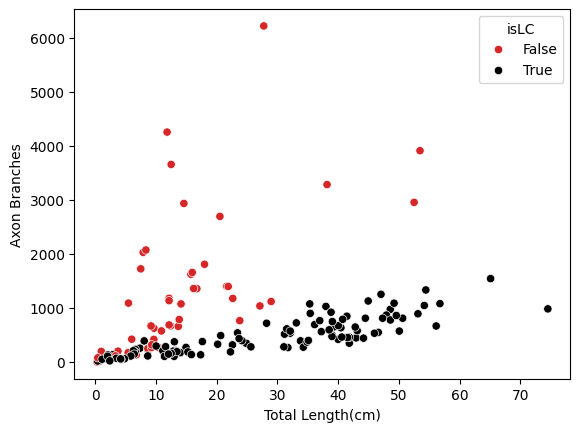

In [92]:
sns.scatterplot(plotManualDF.merge(dfLengths,left_on="Graph",right_index=True),x = "Total Length(cm)", y = "Axon Branches", 
                hue = "isLC", palette = {True:'k', False:'tab:red'})
# plt.legend(["Spinal Projection","Fully Traced"])
# plt.savefig("../results/LC total length vs branch count.svg",dpi=300,bbox_inches='tight')
plt.savefig("../results/LC and non-LC total length vs branch count.svg",dpi=300,bbox_inches='tight')

## Plot lengths